In [4]:
import jax.random as random
import jax.numpy as jnp
from qfso.models.iqp import IQPTensorNetwork, local_gates

nqubits = 5
gate_list = local_gates(nqubits, max_weight=3)
iqp = IQPTensorNetwork(nqubits=nqubits, interactions=gate_list)

key = random.PRNGKey(42)
params = random.uniform(key, shape=(len(gate_list),), minval=0, maxval=2*jnp.pi)

circuit = iqp.build_circuit(parameters=params)

### Expectation value

In [3]:
from qfso.models.iqp import expvals_sampling, expvals_mc, expvals_contraction
from qfso.utils import convert_to_jnp_ndarray

operators = [(0,1),(1,2),(3,4)]
expval_exact = expvals_contraction(circ=circuit, sites=operators)

operators_vec = convert_to_jnp_ndarray(operators, n_qubits=5)
generators = convert_to_jnp_ndarray(gate_list, n_qubits=5)

mean_sample, sigma_sample = expvals_sampling(circuit, operators, 100)
mean_mc, sigma_mc =  expvals_mc(
    params=params, 
    generators=generators, 
    ops=operators_vec, 
    n_samples=1000,
    key=key
    )

/Users/mattiaro/repo/IQP_project/env_3.14_iqp/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Check compatibility

In [13]:
def check():
    if expval_exact.shape != mean_sample.shape:
        raise ValueError(
            f"Forma non compatibile: expval_exact {expval_exact.shape}, "
            f"mean_sample {mean_sample.shape}"
        )

    # Verifica compatibilità tra le due stime: |m1 - m2| <= k * sqrt(s1^2 + s2^2)
    k = 2

    delta = jnp.abs(mean_sample - mean_mc)
    sigma_comb = jnp.sqrt(sigma_sample**2 + sigma_mc**2)
    z = delta / sigma_comb
    compatibili = z <= k

    # Compatibilità con il valore esatto (assumendo incertezza nulla sull'esatto)
    delta_sample_exact = jnp.abs(mean_sample - expval_exact)
    z_sample_exact = delta_sample_exact / sigma_sample
    compat_sample_exact = z_sample_exact <= k

    delta_mc_exact = jnp.abs(mean_mc - expval_exact)
    z_mc_exact = delta_mc_exact / sigma_mc
    compat_mc_exact = z_mc_exact <= k

    print("expval esatto:", expval_exact)

    print("\n[Sample vs MC]")
    print("delta:", delta)
    print("sigma combinata:", sigma_comb)
    print("z-score:", z)
    print(f"Compatibili entro {k}σ:", compatibili)
    print("Compatibilità globale:", bool(jnp.all(compatibili)))

    print("\n[Sample vs Esatto]")
    print("delta:", delta_sample_exact)
    print("z-score:", z_sample_exact)
    print(f"Compatibili entro {k}σ:", compat_sample_exact)
    print("Compatibilità globale:", bool(jnp.all(compat_sample_exact)))

    print("\n[MC vs Esatto]")
    print("delta:", delta_mc_exact)
    print("z-score:", z_mc_exact)
    print(f"Compatibili entro {k}σ:", compat_mc_exact)
    print("Compatibilità globale:", bool(jnp.all(compat_mc_exact)))
check()

expval esatto: [ 0.17861146  0.16566035 -0.28041425]

[Sample vs MC]
delta: [0.03631119 0.18467605 0.10868895]
sigma combinata: [0.10201387 0.10236832 0.1013366 ]
z-score: [0.3559437 1.8040351 1.0725538]
Compatibili entro 2σ: [ True  True  True]
Compatibilità globale: True

[Sample vs Esatto]
delta: [0.07861146 0.06566036 0.08041427]
z-score: [0.78611475 0.65660363 0.8166107 ]
Compatibili entro 2σ: [ True  True  True]
Compatibilità globale: True

[MC vs Esatto]
delta: [0.04230027 0.2503364  0.18910322]
z-score: [ 2.0971773 11.434854   7.9058733]
Compatibili entro 2σ: [False False False]
Compatibilità globale: False


### MMD estimation

In [5]:
import numpy as np
import jax.numpy as jnp
from qfso.models.iqp import median_heuristic
from qfso.utils import convert_to_jnp_ndarray
from qfso.distributions.generate import *
import jax

generators = convert_to_jnp_ndarray(gate_list, n_qubits=5)

n_states = 2**nqubits
target_entropy = jnp.log(n_states) * 0.5
key_dist, key_sample, key = jax.random.split(key, 3)
ground_truth_dist = generate_distribution_with_target_entropy(n_states, target_entropy, key_dist)
ground_truth = sample_dataset_from_distribution(ground_truth_dist, nqubits, 10000, key_sample)


sigma = median_heuristic(X=ground_truth)


In [6]:
from qfso.models.iqp import mmd_mc

mmd = mmd_mc(
    params=params,
    generators=generators,
    ground_truth=ground_truth,
    sigma=sigma,
    n_ops= 20, # max = 2^nqubits
    n_samples=10000,
    key=key,
)


# from iqpopt.gen_qml import mmd_loss_iqp
# from iqpopt import IqpSimulator
# from iqpopt.utils import local_gates as local_gates_iqpopt

# gate_list_iqpopt = local_gates_iqpopt(nqubits, max_weight=3)

# circuit_iqpot = IqpSimulator(
#     n_qubits=nqubits,
#     gates=gate_list_iqpopt,
# )

# mmd_iqpot = mmd_loss_iqp(
#     params=params,
#     iqp_circuit=circuit_iqpot,
#     ground_truth=ground_truth,
#     sigma=sigma[0],
#     n_ops=20,
#     n_samples=10000,
#     key=key
# )

# print("mmd (MC):", mmd)
# print("mmd (IQPOpt):", mmd_iqpot)
# if jnp.isclose(mmd, mmd_iqpot, atol=1e-2):
#     print("They match! 😊")
mmd**2

0.0007279503311100922

### Training IQP model

In [2]:
from tqdm import tqdm

import numpy as np
import jax.random as random
import jax.numpy as jnp
import matplotlib.pyplot as plt

from qfso.models.iqp import IQPTensorNetwork, local_gates, sigma_heuristic, setup_training
from qfso.utils import convert_to_jnp_ndarray

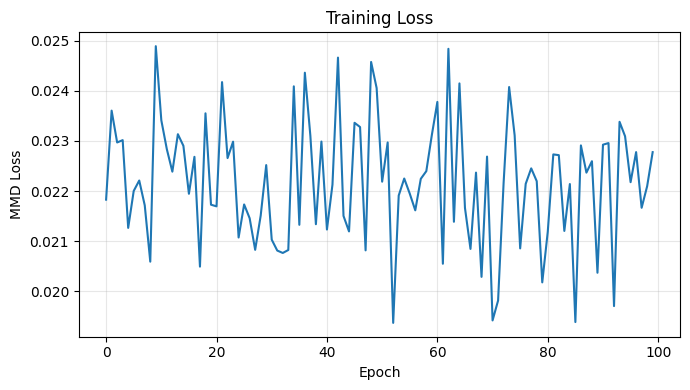

In [38]:
# hyperparameters
nqubits = 25
# sigma = 0.1 * nqubits
sigma = sigma_heuristic(X=ground_truth)
key = random.PRNGKey(42)


# circuit initialization
gate_list = local_gates(nqubits, max_weight=2)
iqp = IQPTensorNetwork(nqubits=nqubits, interactions=gate_list)
params = random.uniform(key, shape=(len(gate_list),), minval=0, maxval=2*jnp.pi)
circuit = iqp.build_circuit(parameters=params)

generators = convert_to_jnp_ndarray(gate_list, n_qubits=nqubits)
ground_truth = jnp.asarray(np.load("../datasets/ising_L5_T2.4_h0.08.npy"))

opt_state, train_step = setup_training(
    init_params=params, 
    generators=generators, 
    ground_truth=ground_truth, 
    sigma=sigma, 
    n_ops=10000, 
    n_samples=1000, 
    lr=0.02,
)

epochs = 100
loss_history = []
for _ in tqdm(range(epochs), desc="Training", leave=False):
    key, subkey = random.split(key)
    params, opt_state, loss_val = train_step(params, opt_state, subkey)
    loss_history.append(loss_val)


loss_history_np = np.asarray(jnp.stack(loss_history))
params_np = np.asarray(params)
np.savez(
    "training_results.npz",
    loss_history=loss_history_np,
    params=params_np,
    epochs=epochs,
    nqubits=nqubits,
    sigma=float(sigma),
)


plt.figure(figsize=(7, 4))
plt.plot(loss_history_np)
plt.xlabel("Epoch")
plt.ylabel("MMD Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()